# Employee Burnout Predictor

In [71]:
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, chi2_contingency, mannwhitneyu, kruskal, f_oneway
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             accuracy_score, f1_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

In [72]:
# Download latest version
path = kagglehub.dataset_download("suhanigupta04/employee-mental-health-and-burnout-dataset")

print("Path to dataset files:", path,)


Path to dataset files: C:\Users\DELL\.cache\kagglehub\datasets\suhanigupta04\employee-mental-health-and-burnout-dataset\versions\1


## Load the dataset and do a quick explore

In [73]:
print(os.listdir(path))

['tech_mental_health_burnout.csv']


In [74]:
df = pd.read_csv(os.path.join(path,"tech_mental_health_burnout.csv"))
print("Shape of the datset:",df.shape)
df.head(5)

Shape of the datset: (150000, 25)


,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


In [75]:
df.columns

Index(['age', 'gender', 'job_role', 'experience_years', 'company_size',
       'work_mode', 'work_hours_per_week', 'overtime_hours',
       'meetings_per_day', 'deadlines_missed', 'job_satisfaction',
       'manager_support', 'work_life_balance', 'sleep_hours',
       'physical_activity_days', 'screen_time_hours', 'caffeine_intake',
       'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score',
       'depression_score', 'burnout_score', 'burnout_level',
       'seeks_professional_help'],
      dtype='object')

In [76]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,150000.0,38.03,9.51,22.0,30.0,38.0,46.0,54.0
experience_years,150000.0,5.06,2.88,0.0,3.0,5.0,7.0,18.5
work_hours_per_week,150000.0,47.01,7.89,30.0,42.0,47.0,52.0,84.0
overtime_hours,150000.0,6.13,3.78,0.0,3.0,6.0,9.0,24.0
meetings_per_day,150000.0,4.01,1.98,0.0,3.0,4.0,5.0,12.0
deadlines_missed,150000.0,1.28,1.43,0.0,0.0,1.0,2.0,5.0
job_satisfaction,150000.0,5.50,1.96,1.0,4.2,5.5,6.9,10.0
manager_support,150000.0,5.50,1.96,1.0,4.1,5.5,6.8,10.0
work_life_balance,150000.0,5.02,1.95,1.0,3.7,5.0,6.4,10.0
sleep_hours,150000.0,6.50,1.19,3.0,5.7,6.5,7.3,10.0


In [77]:
df.dtypes

age                          int64
gender                      object
job_role                    object
experience_years           float64
company_size                object
work_mode                   object
work_hours_per_week        float64
overtime_hours             float64
meetings_per_day           float64
deadlines_missed             int64
job_satisfaction           float64
manager_support            float64
work_life_balance          float64
sleep_hours                float64
physical_activity_days       int64
screen_time_hours          float64
caffeine_intake              int64
social_support_score       float64
has_therapy                  int64
stress_level               float64
anxiety_score              float64
depression_score           float64
burnout_score              float64
burnout_level               object
seeks_professional_help      int64
dtype: object

In [78]:
categorical_cols = df.select_dtypes(include=["object"]).columns.to_list()
numerical_cols =  df.select_dtypes(include=[np.number]).columns.to_list()
print(categorical_cols)
print("-"*20)
print(numerical_cols)

['gender', 'job_role', 'company_size', 'work_mode', 'burnout_level']
--------------------
['age', 'experience_years', 'work_hours_per_week', 'overtime_hours', 'meetings_per_day', 'deadlines_missed', 'job_satisfaction', 'manager_support', 'work_life_balance', 'sleep_hours', 'physical_activity_days', 'screen_time_hours', 'caffeine_intake', 'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score', 'depression_score', 'burnout_score', 'seeks_professional_help']


In [79]:
for col in categorical_cols:
    print(col, df[col].unique())
    print("-"*20)

gender ['Female' 'Male' 'Non-binary']
--------------------
job_role ['Backend Developer' 'Frontend Developer' 'DevOps' 'Data Scientist'
 'Software Engineer' 'Product Manager' 'QA Engineer' 'ML Engineer']
--------------------
company_size ['Large' 'Mid-size' 'MNC' 'Startup']
--------------------
work_mode ['Hybrid' 'Remote' 'Onsite']
--------------------
burnout_level ['Low' 'Moderate' 'High']
--------------------


In [80]:
df[categorical_cols].nunique()

gender           3
job_role         8
company_size     4
work_mode        3
burnout_level    3
dtype: int64

## EDA

### Missing values

In [81]:
tble=[]
missing_values = df[col].isnull().sum()
missing_pct = (missing_values / len(df) * 100).round(2)
missing_pct

for col in df.columns:
    tble.append({
        "column_name":col,
        "Count_of_missing_values":missing_values,
        "Missing_%":missing_pct
    })
pd.DataFrame(tble,index=None)

,column_name,Count_of_missing_values,Missing_%
0,age,0,0.0
1,gender,0,0.0
2,job_role,0,0.0
3,experience_years,0,0.0
4,company_size,0,0.0
5,work_mode,0,0.0
6,work_hours_per_week,0,0.0
7,overtime_hours,0,0.0
8,meetings_per_day,0,0.0
9,deadlines_missed,0,0.0


Data looks clean!

### Analysis on Target labels

In [82]:
df["burnout_level"].unique()

array(['Low', 'Moderate', 'High'], dtype=object)

In [83]:
burnout_lvl_count = df["burnout_level"].value_counts()
columns=["Low","Moderate","High"]
burnout_lvl_count = burnout_lvl_count.reindex(columns)
burnout_lvl_count

burnout_level
Low         131620
Moderate     18315
High            65
Name: count, dtype: int64

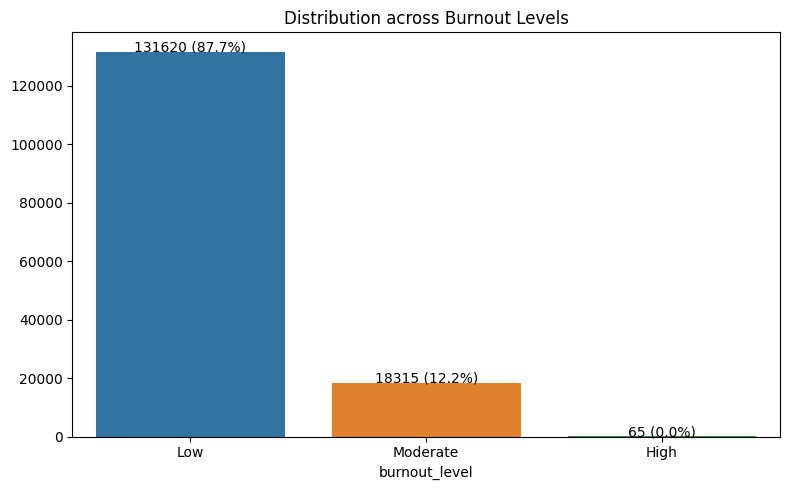

In [84]:
fig,ax = plt.subplots(figsize=(8,5))
sns.barplot(
    x=burnout_lvl_count.index,
    y=burnout_lvl_count.values,
    hue=burnout_lvl_count.index,
    ax=ax,
    )

total = burnout_lvl_count.sum()

for i,v in enumerate(burnout_lvl_count.values):
    pct=(v/total)*100
    ax.text(
        i,
        v+50,
        s=f"{v} ({pct:.1f}%)",
        ha="center"
    )
plt.title("Distribution across Burnout Levels")
plt.tight_layout()
plt.show()

**Key Takeaways**

- The target variable is highly imbalanced, with nearly 88% of the records belonging to the Low burnout level. 
- Such an imbalance can affect model performance, as the model may favor the majority class (Low) while underperforming on the minority classes (Moderate and High)

In [85]:
burnout_score_mean = df["burnout_score"].mean()
burnout_score_median = df["burnout_score"].median()

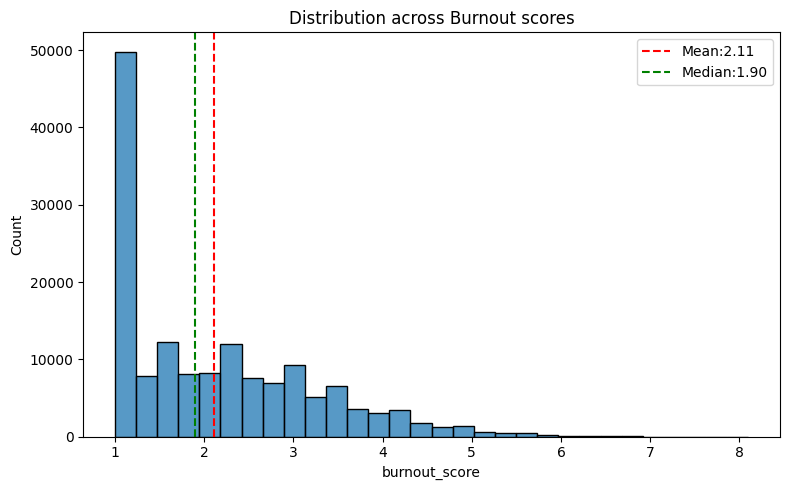

In [86]:

fig,ax = plt.subplots(figsize=(8,5))
sns.histplot(
    df['burnout_score'],
    bins=30
    )
ax.axvline(burnout_score_mean,linestyle="--",color="red",
           label=f"Mean:{burnout_score_mean:.2f}")
ax.axvline(burnout_score_median,linestyle="--",color="green",
           label=f"Median:{burnout_score_median:.2f}")
ax.legend()

plt.title("Distribution across Burnout scores")
plt.tight_layout()
plt.show()

**Key takeaways**

- There's a huge concentration from scores 1 to 2 and scores where higher scores beyond 5 shows minimal.
- Mean(2.11) is greater than Median(1.90) confirms that it's positively right skewed
- This distribution aligns with the previous findings that why low burnout levels has higher number of counts which dominates the dataset.

### Numerical Features Analysis

#### Univariate Analysis

In [87]:
df[numerical_cols].head()

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,seeks_professional_help
0,50,7.8,45.0,0.0,5.0,0,5.9,5.1,6.1,5.9,2,8.6,1,4.4,0,4.8,4.3,2.6,1.0,0
1,36,1.8,56.0,4.0,6.0,0,6.3,5.2,1.1,7.1,1,11.5,4,4.1,0,6.7,4.8,4.6,3.7,0
2,29,2.5,43.0,2.0,6.0,3,8.4,5.9,6.2,5.1,0,6.8,3,6.5,0,4.5,4.0,2.5,1.0,0
3,42,1.5,57.0,9.0,4.0,1,7.0,3.2,5.3,6.9,6,10.2,5,2.5,0,6.1,5.8,1.8,3.6,0
4,40,3.4,49.0,0.0,3.0,4,5.6,2.4,3.9,7.3,2,11.9,5,4.6,0,7.2,5.9,2.4,3.5,0


In [88]:
df[numerical_cols].columns

Index(['age', 'experience_years', 'work_hours_per_week', 'overtime_hours',
       'meetings_per_day', 'deadlines_missed', 'job_satisfaction',
       'manager_support', 'work_life_balance', 'sleep_hours',
       'physical_activity_days', 'screen_time_hours', 'caffeine_intake',
       'social_support_score', 'has_therapy', 'stress_level', 'anxiety_score',
       'depression_score', 'burnout_score', 'seeks_professional_help'],
      dtype='object')

##### Descriptive Statistics

In [89]:
stats_lst = []
for col in df[numerical_cols].columns:
     stats_lst.append({
        "Column Name":col,
        "Mean":round(df[col].value_counts(ascending=False).mean(),2),
        "Median":df[col].value_counts(ascending=False).median(),
        "Mode":df[col].value_counts(ascending=False).mode()[0],
        "Variance":round(df[col].value_counts(ascending=False).var(),2),
        "Std. Deviation":round(df[col].value_counts(ascending=False).std(),2), 
        "Skewness":round(df[col].value_counts(ascending=False).skew(),2), 
        "Kurtosis":round(df[col].value_counts(ascending=False).kurtosis(),2),                 
    })

pd.DataFrame(stats_lst)

,Column Name,Mean,Median,Mode,Variance,Std. Deviation,Skewness,Kurtosis
0,age,4545.45,4548.0,4474,3.719440e+03,60.99,0.26,1.18
1,experience_years,872.09,729.5,1,7.928519e+05,890.42,2.58,17.01
2,work_hours_per_week,2884.62,2236.0,1,7.202501e+06,2683.75,0.47,-1.28
3,overtime_hours,6000.00,4903.0,1,3.348440e+07,5786.57,0.31,-1.63
4,meetings_per_day,11538.46,9714.0,11,1.196652e+08,10939.16,0.52,-1.29
5,deadlines_missed,25000.00,18722.0,5883,4.249730e+08,20614.87,1.14,0.60
6,job_satisfaction,1648.35,1660.0,251,8.611276e+05,927.97,0.02,-1.44
7,manager_support,1648.35,1616.0,258,8.560005e+05,925.20,0.01,-1.43
8,work_life_balance,1648.35,1655.0,3001,9.169860e+05,957.59,0.03,-1.38
9,sleep_hours,2112.68,1656.0,934,3.049789e+06,1746.36,0.39,-1.39


##### Visual Analysis using Histogram & Boxplot

Distribution of all numerical features (black=Mean green=Median)


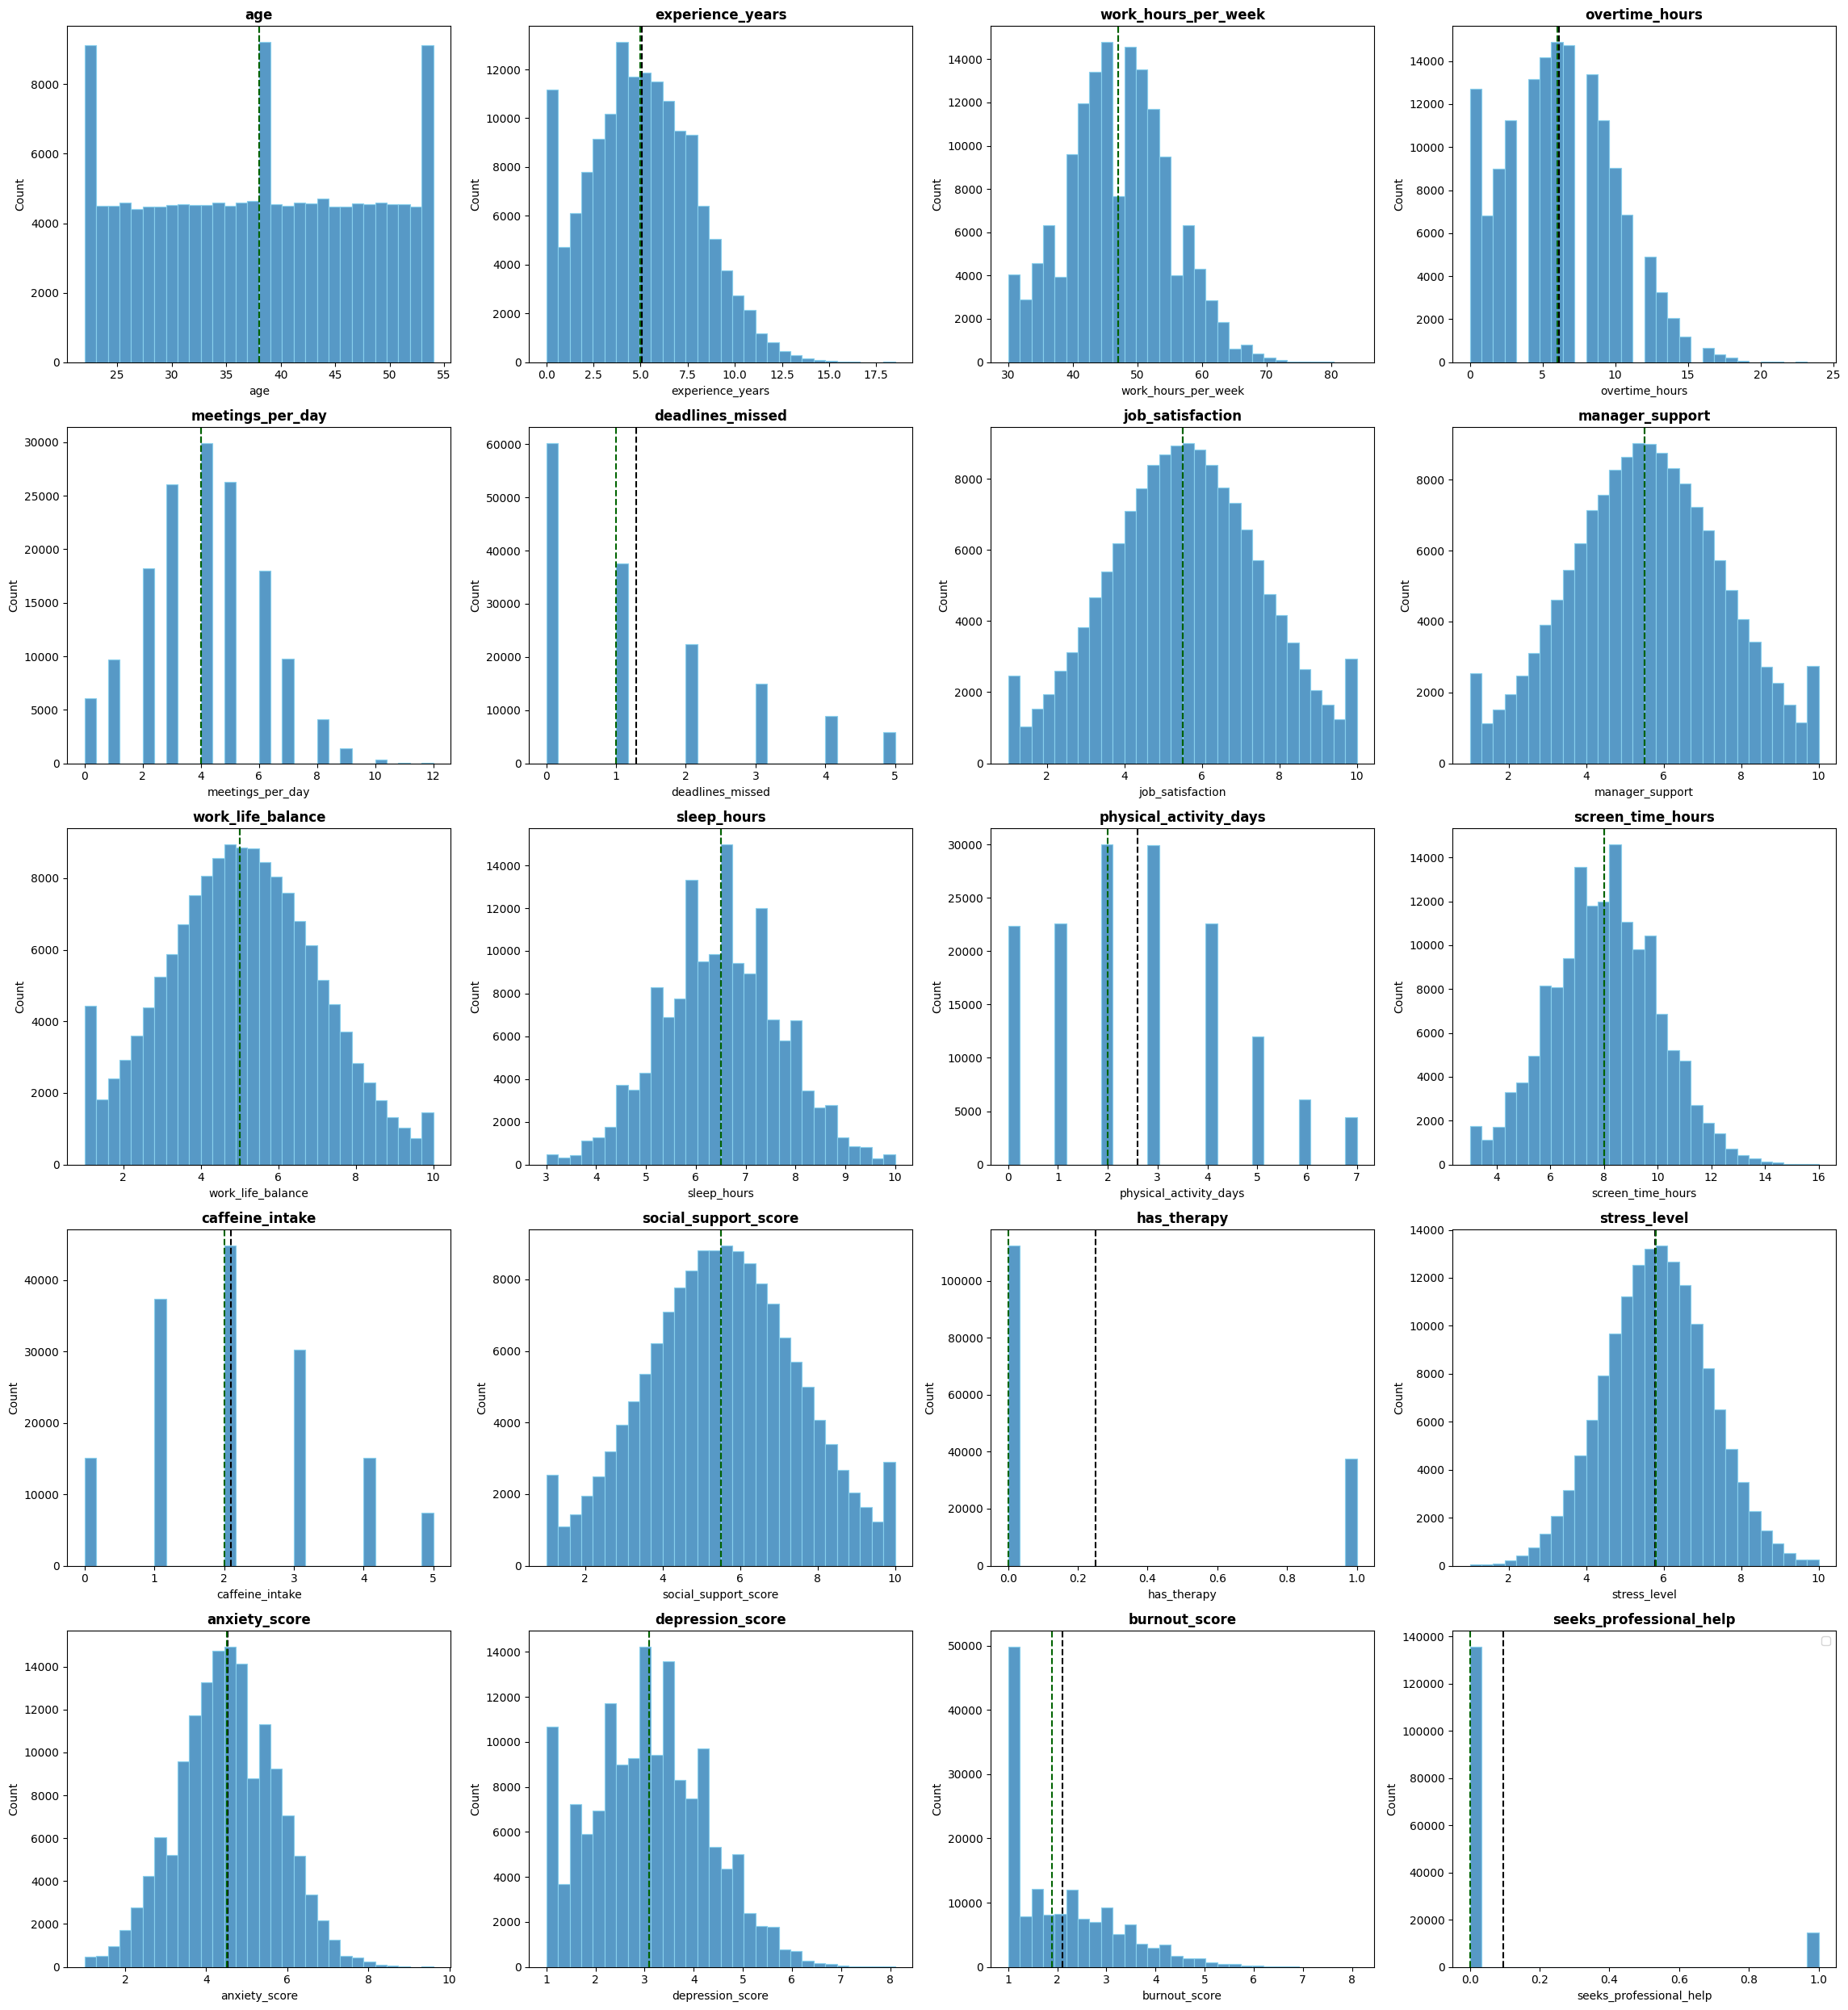

In [90]:
fig, axes = plt.subplots(5, 4, figsize=(23, 25))
axes = axes.flatten()

# Iterating all to display all numerical histogram in one chart display using subplots
for i,col in enumerate(df[numerical_cols]):
    sns.histplot(df[col],bins=30,edgecolor="skyblue",ax=axes[i])
    axes[i].axvline(df[col].mean(),color="black",linestyle="--")
    axes[i].axvline(df[col].median(),color="darkgreen",linestyle="--")
    axes[i].set_title(col, fontweight='bold')

# Hide unused subplots
for j in range(len(df[numerical_cols]), len(axes)):
    axes[j].set_visible(False)

print("Distribution of all numerical features (black=Mean green=Median)")
plt.legend()
plt.tight_layout()
plt.show()

**Overall Distribution Analysis**
- Most numerical features appear approximately symmetric and bell-shaped, with the mean and median closely aligned, indicating limited skewness.
- Features such as job_satisfaction, manager_support, work_life_balance, social_support_score, stress_level, and anxiety_score show near-normal distributions centered around their middle values.

**Positively Skewed Features**
- burnout_score is strongly right-skewed, with most observations concentrated at lower values and a long tail extending toward higher scores.
- overtime_hours exhibits moderate positive skewness, suggesting most employees work relatively few overtime hours while a smaller group works substantially more
experience_years also shows positive skewness, indicating fewer individuals with very high experience levels.

**Discrete / Count-Based Variables**
- meetings_per_day, deadlines_missed, physical_activity_days, and caffeine_intake are discrete variables, resulting in visible spikes rather than smooth distributions.
- deadlines_missed is concentrated heavily around 0–1 missed deadlines, indicating most individuals miss few deadlines.

**Binary Variables**
- has_therapy and seeks_professional_help are binary features.
- Both variables are highly imbalanced, particularly seeks_professional_help, where one category dominates the dataset.

**Uniform Distribution**
- age appears nearly uniformly distributed across the observed range, indicating balanced representation of age groups in the dataset.

**Mental Health Indicators**
- stress_level, anxiety_score, and depression_score are centered around moderate values rather than extreme values, suggesting that severe mental health symptoms are relatively less common in the dataset.


Outlier levels from Numerical columns


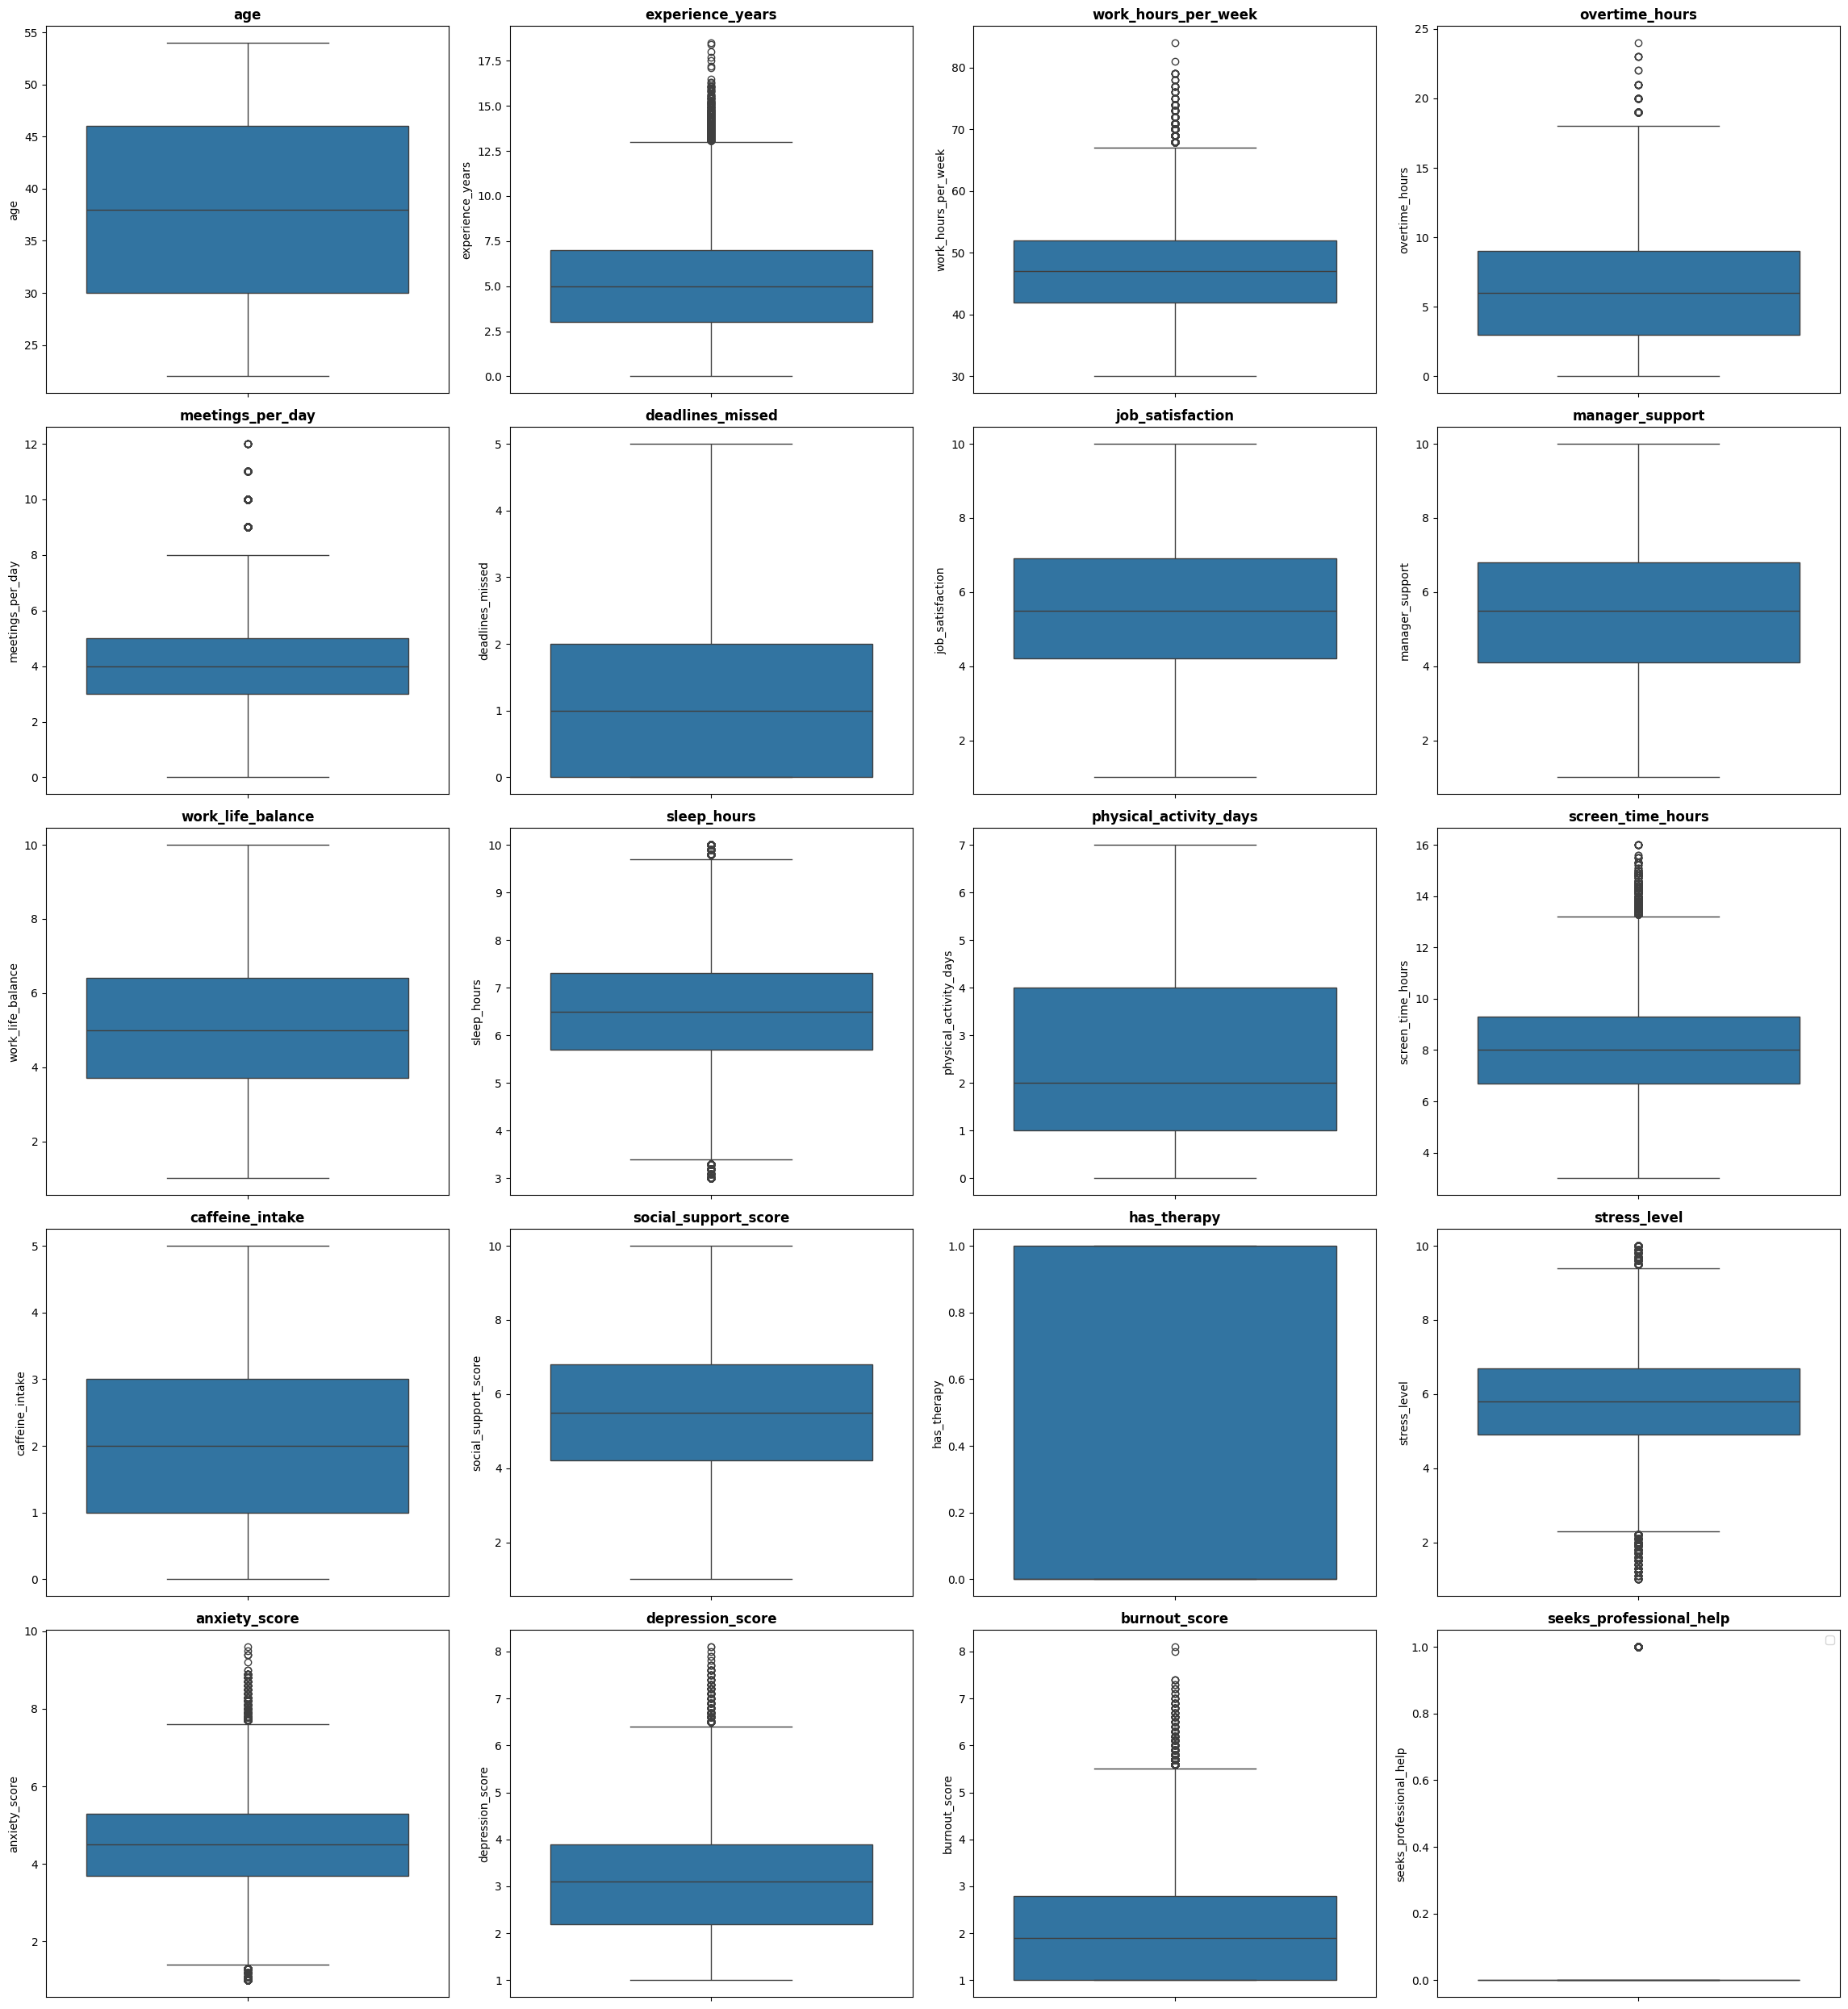

In [91]:
fig, axes = plt.subplots(5, 4, figsize=(23, 25))
axes = axes.flatten()

for i,col in enumerate(df[numerical_cols]):
    sns.boxplot(data=df[col],ax=axes[i])
    axes[i].set_title(col, fontweight='bold')

print("Outlier levels from Numerical columns")
plt.legend()
plt.tight_layout()
plt.show()

### Categorical Features Analysis

#### Univariate Analysis

In [92]:
df[categorical_cols].head()

,gender,job_role,company_size,work_mode,burnout_level
0,Female,Backend Developer,Large,Hybrid,Low
1,Male,Frontend Developer,Mid-size,Remote,Moderate
2,Male,DevOps,MNC,Hybrid,Low
3,Female,Backend Developer,Mid-size,Hybrid,Moderate
4,Female,Frontend Developer,Large,Remote,Low


In [93]:
for col in df[categorical_cols]:
    print(df[col].value_counts())
    print("-"*20)

gender
Male          82286
Female        60281
Non-binary     7433
Name: count, dtype: int64
--------------------
job_role
Software Engineer     37623
Data Scientist        22442
ML Engineer           18153
Backend Developer     18079
Frontend Developer    17967
DevOps                14897
Product Manager       11925
QA Engineer            8914
Name: count, dtype: int64
--------------------
company_size
Large       37623
Startup     37560
MNC         37461
Mid-size    37356
Name: count, dtype: int64
--------------------
work_mode
Hybrid    60056
Remote    52471
Onsite    37473
Name: count, dtype: int64
--------------------
burnout_level
Low         131620
Moderate     18315
High            65
Name: count, dtype: int64
--------------------


In [94]:
uni_cats = [c for c in categorical_cols if c!="burnout_level"]
uni_cats

['gender', 'job_role', 'company_size', 'work_mode']

Distribution across Categorical labels


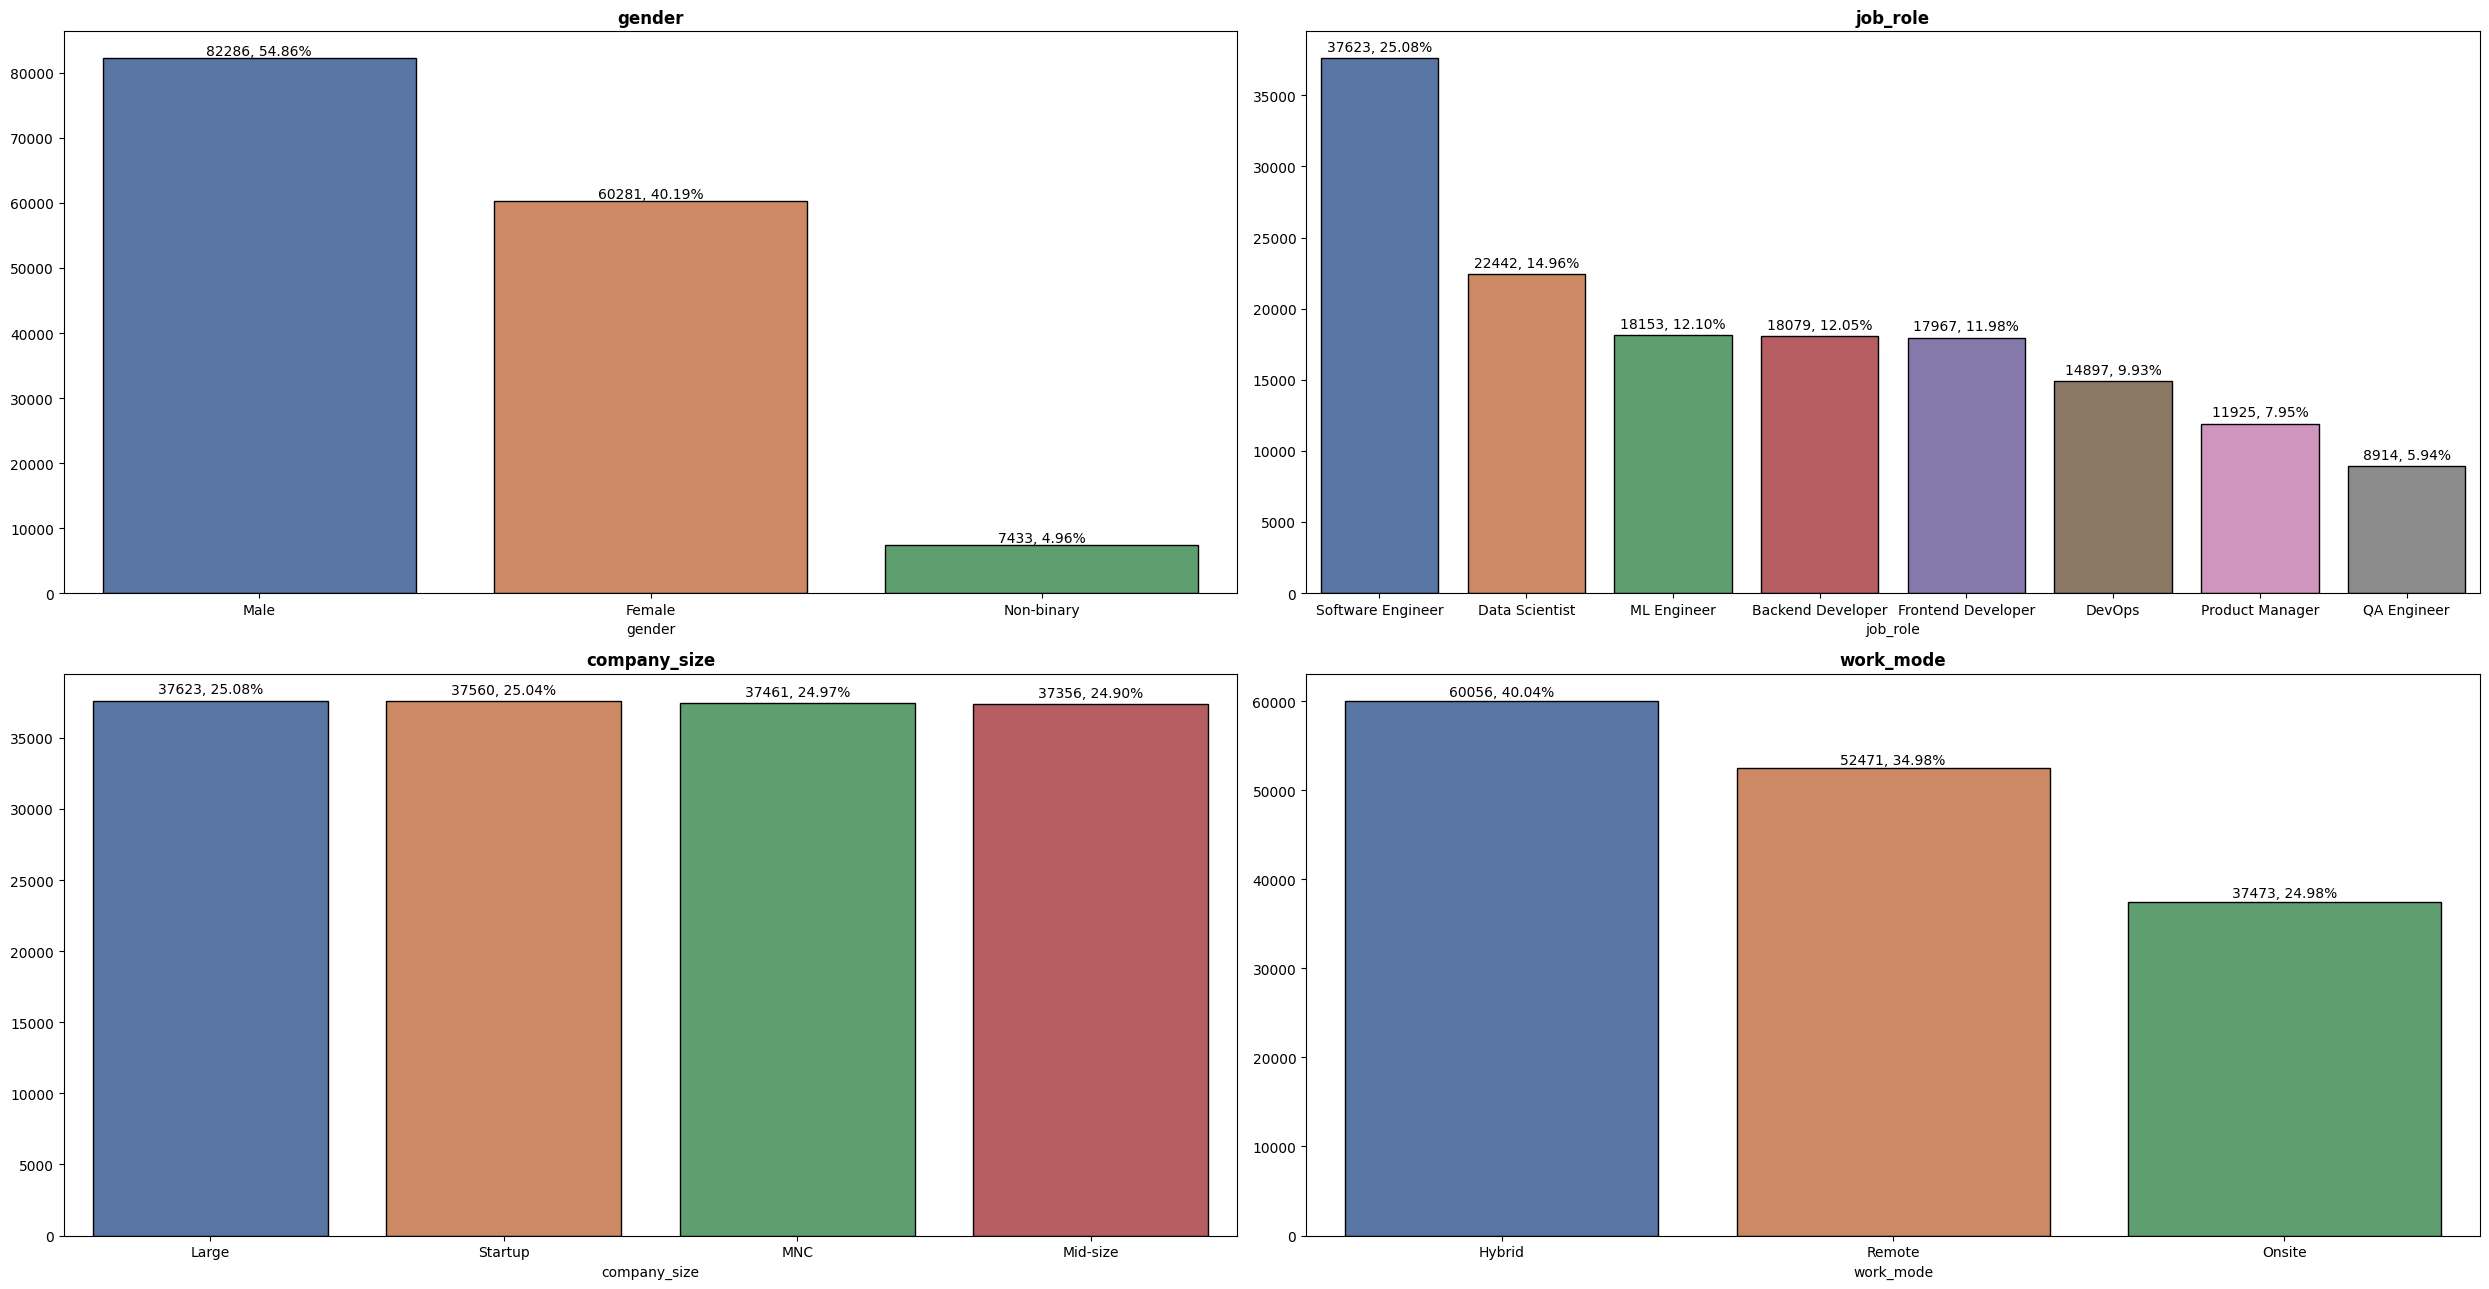

In [95]:
fig, axes = plt.subplots(2, 2, figsize=(25, 13))
axes = axes.flatten()

for idx, col in enumerate(uni_cats):
    count = df[col].value_counts()

    sns.barplot(
        x=count.index,
        y=count.values,
        palette=sns.color_palette('deep', len(count)),
        edgecolor="black",
        ax=axes[idx]
    )

    axes[idx].set_title(col, fontweight='bold')

    total = count.sum()

    for j, v in enumerate(count.values):
        pct =(v/total) *100
        axes[idx].text(
            j,
            v + 500,
            f"{v}, {pct:.2f}%",
            ha="center"
        )
print("Distribution across Categorical labels")
plt.tight_layout()
plt.show()

#### Bivariate Analysis

Outlier analysis - Burnout Level vs Numerical features


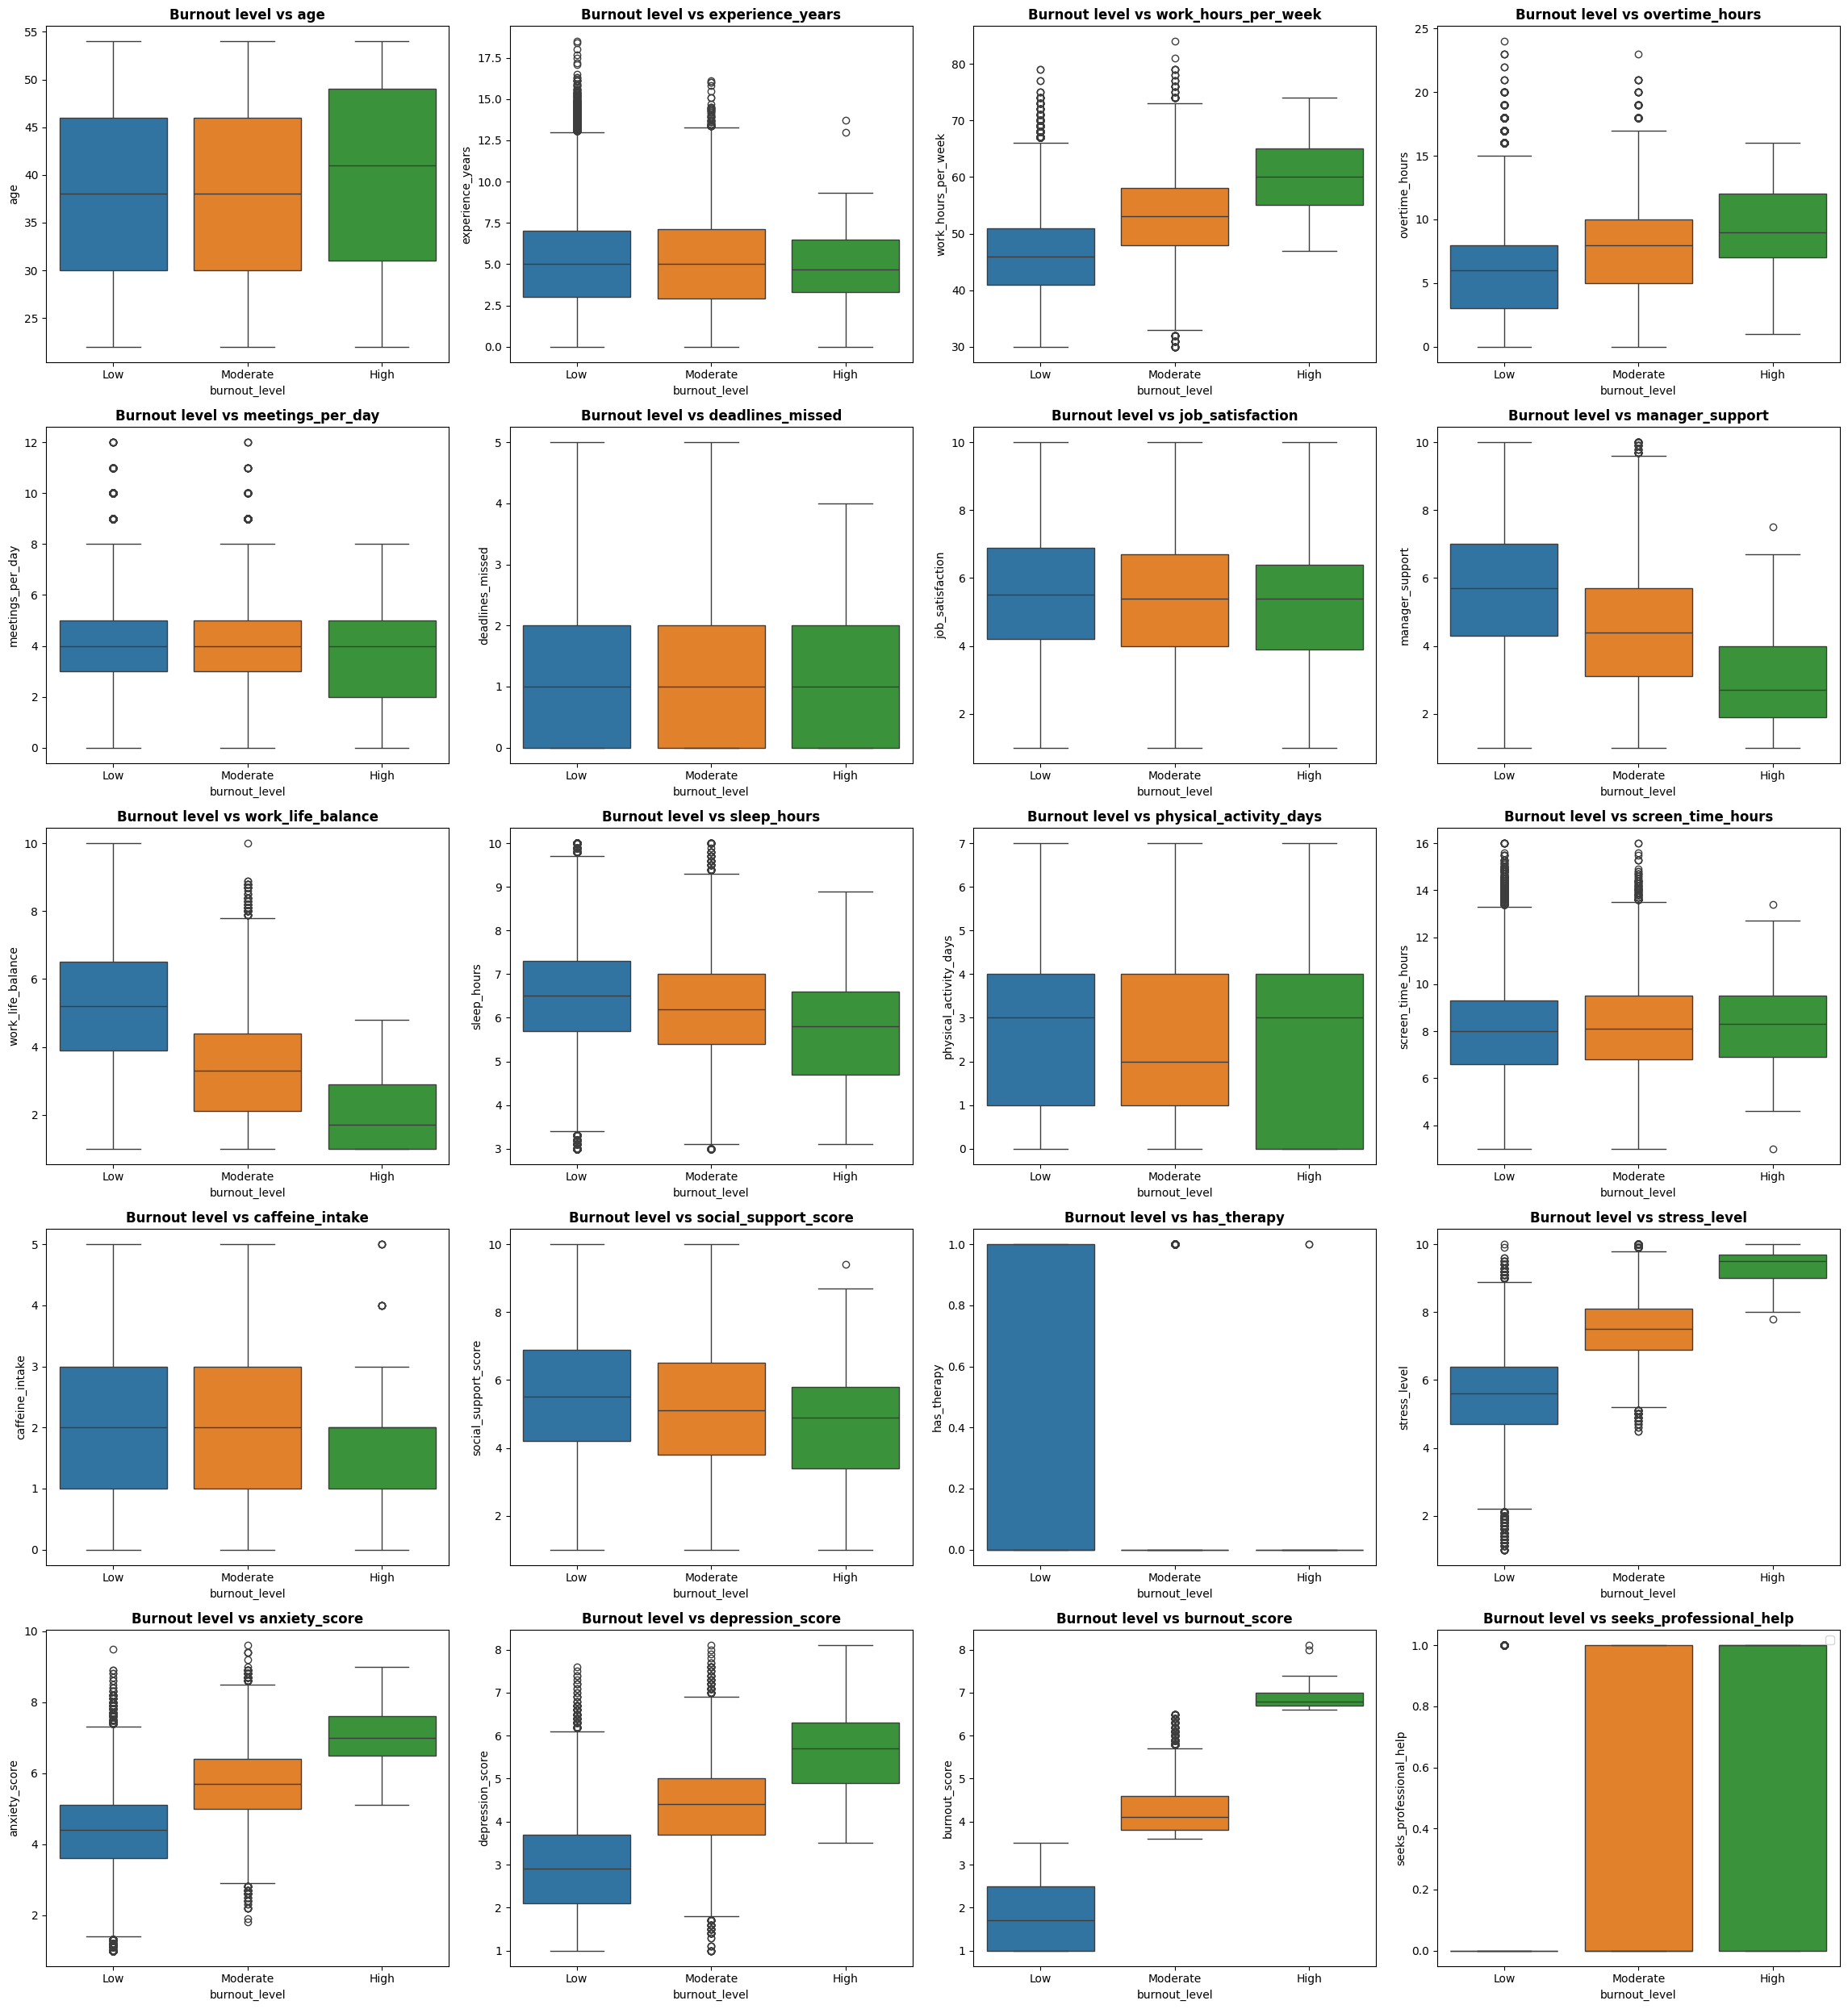

In [96]:
fig, axes = plt.subplots(5, 4, figsize=(23, 25))
axes = axes.flatten()

for i,col in enumerate(df[numerical_cols]):
    sns.boxplot(
        data=df,
        x="burnout_level",
        y=col,
        hue="burnout_level",
        ax=axes[i]
        )
    axes[i].set_title(f"Burnout level vs {col}", fontweight='bold')

print("Outlier analysis - Burnout Level vs Numerical features")
plt.legend()
plt.tight_layout()
plt.show()

**📈 Strong Relationships**
- Numerical features such as stress_level. anixety_score and depression_score shows an increase median by burnout_levels and clears upward trend
- This strongly shows that it is associated with burnout

**📉 Negative Relationships**
- Downward trends such as work-life balance, manager support and sleeping hours indicates a negative association and inverse relationship of burnout

**Positive Workload Factors**
- Employees working hours including overtime hours increases noticeably across burnout levels.
- Employees with higher amount of burnout generally works more hours per week

**Weak Relationships**
- Age, Experience Years, Meetings per day, Deadlines missed, physical activities and caffeine intake shows similar medians and some shown slight differnces and IQRs which indicated limited relationship across burnout levels

**Binary features**
- has_theraphy: most low burnout individuals are not taking therapy and differs across burnout categories
- seek_professional_help: Moderate and High burnout groups show much higher rates of seeking professional help.


#### Binary Features Analysis

In [97]:
binary_cols = [
    col for col in numerical_cols
    if set(df[col].dropna().unique()) <= {0, 1}
]

print(binary_cols)

['has_therapy', 'seeks_professional_help']


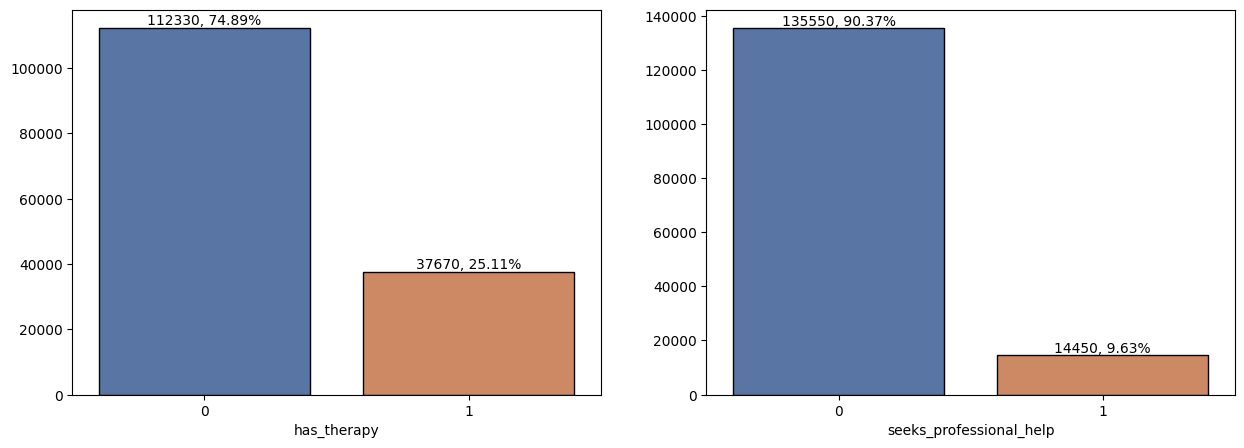

In [98]:
fig, axes = plt.subplots(1,2,figsize=(15,5))
axes = axes.flatten()

for idx, col in enumerate(binary_cols):
    count = df[col].value_counts()

    sns.barplot(
        x=count.index,
        y=count.values,
        palette=sns.color_palette('deep', len(count)),
        edgecolor="black",
        ax=axes[idx]
    )
    for j, v in enumerate(count.values):
        pct =(v/total) *100
        axes[idx].text(
            j,
            v + 900,
            f"{v}, {pct:.2f}%",
            ha="center"
        )

### Outlier Analysis

In [99]:
outlier_analysis_cols = df[numerical_cols].drop(columns=["has_therapy","seeks_professional_help"])

In [100]:
def detect_outliers_iqr(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lowerbound = Q1 - factor * IQR
    upperbound = Q3 + factor * IQR
    return lowerbound,upperbound,IQR    

In [101]:
outlier_details = {}
for col in outlier_analysis_cols:
    lower,upper,IQR = detect_outliers_iqr(df[col])
    
    outliers = (df[col] < lower) | (df[col] > upper)

    outlier_details[col] = {
        "Lower Bound": round(lower,2),
        "Upper Bound": round(upper,2),
        "IQR": round(IQR,2),
        "Number of Outliers": outliers.sum(),
        "Outlier %": round(outliers.sum()/df[col].shape[0],2) 
    }
    
outlier_data = pd.DataFrame(outlier_details)
outlier_data= outlier_data.T
outlier_data[outlier_data["Number of Outliers"]>0]

,Lower Bound,Upper Bound,IQR,Number of Outliers,Outlier %
experience_years,-3.00,13.00,4.0,537.0,0.00
work_hours_per_week,27.00,67.00,10.0,752.0,0.01
overtime_hours,-6.00,18.00,6.0,112.0,0.00
meetings_per_day,0.00,8.00,2.0,1811.0,0.01
sleep_hours,3.30,9.70,1.6,1073.0,0.01
screen_time_hours,2.80,13.20,2.6,679.0,0.00
stress_level,2.20,9.40,1.8,927.0,0.01
anxiety_score,1.30,7.70,1.6,1246.0,0.01
depression_score,-0.35,6.45,1.7,395.0,0.00
burnout_score,-1.70,5.50,1.8,748.0,0.00


- The IQR-based outlier analysis revealed that most numerical features contain a very small proportion of outliers (≤1%), indicating generally clean and well-behaved data.
- Outliers in variables such as work_hours_per_week, overtime_hours, and burnout_score primarily represent legitimate extreme observations rather than data quality issues.

It's best to keep all outliers since its not measurement errors.
Tree based models are preferred to use which handle outliers naturally

### Correlation Analysis

#### Correlation Matrix with burnout score

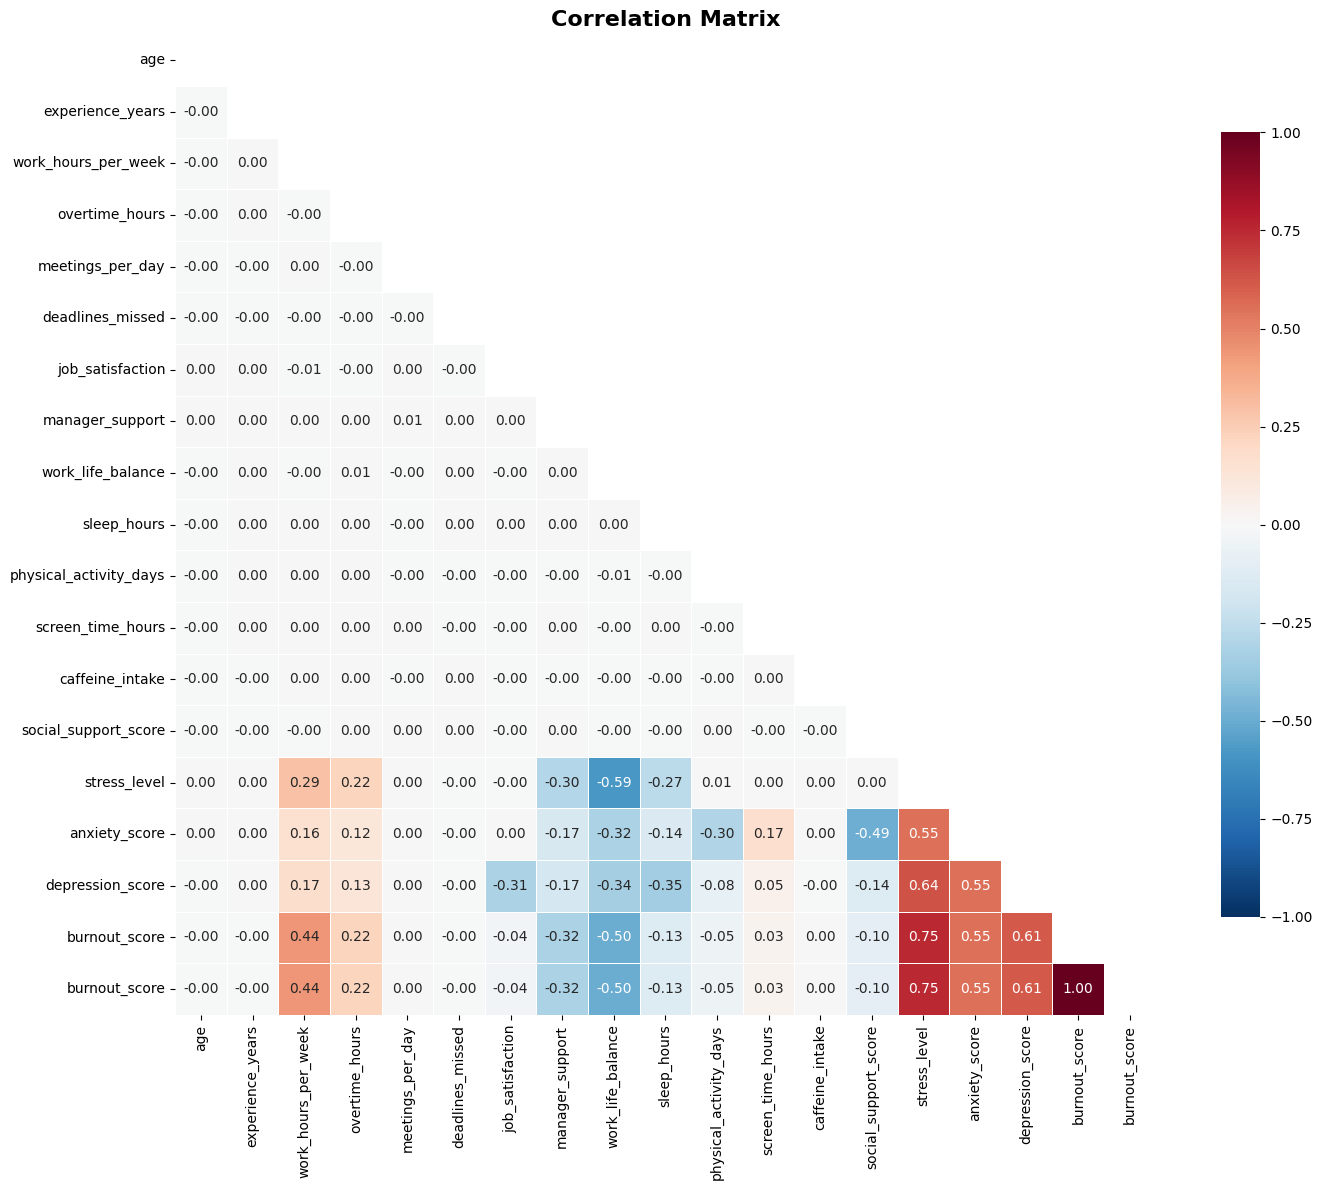

In [102]:
corr_cols = [c for c in numerical_cols if c not in binary_cols]
corr_matrix = df[corr_cols + ['burnout_score']].corr()

fig, ax = plt.subplots(figsize=(15, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Top Correlation features with burnout score

In [103]:
corr_matrix

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,stress_level,anxiety_score,depression_score,burnout_score,burnout_score
age,1.000000,-0.001317,-0.002374,-0.001275,-0.000372,-0.001470,0.003923,0.002771,-0.002718,-0.001969,-0.001251,-0.001931,-0.001288,-0.000459,0.000281,0.000303,-0.001763,-0.001800,-0.001800
experience_years,-0.001317,1.000000,0.003697,0.000824,-0.002055,-0.001120,0.003895,0.001142,0.001237,0.002509,0.000958,0.000726,-0.002549,-0.001465,0.001188,0.000036,0.000532,-0.000691,-0.000691
work_hours_per_week,-0.002374,0.003697,1.000000,-0.004648,0.001536,-0.000657,-0.006389,0.000711,-0.001110,0.003725,0.002098,0.000361,0.001278,-0.001807,0.293580,0.162561,0.173718,0.439901,0.439901
overtime_hours,-0.001275,0.000824,-0.004648,1.000000,-0.002192,-0.002617,-0.002267,0.004314,0.005116,0.000482,0.003044,0.001711,0.002156,0.001959,0.222274,0.121404,0.131802,0.218801,0.218801
meetings_per_day,-0.000372,-0.002055,0.001536,-0.002192,1.000000,-0.003956,0.000868,0.005928,-0.000771,-0.002543,-0.004900,0.000882,-0.000490,0.001781,0.001347,0.001316,0.001199,0.000182,0.000182
deadlines_missed,-0.001470,-0.001120,-0.000657,-0.002617,-0.003956,1.000000,-0.004622,0.002509,0.001076,0.002955,-0.000508,-0.004575,0.000075,0.001050,-0.003146,-0.000677,-0.000820,-0.002454,-0.002454
job_satisfaction,0.003923,0.003895,-0.006389,-0.002267,0.000868,-0.004622,1.000000,0.002303,-0.001674,0.002212,-0.000261,-0.000351,-0.002873,-0.003742,-0.002801,0.000761,-0.314320,-0.038412,-0.038412
manager_support,0.002771,0.001142,0.000711,0.004314,0.005928,0.002509,0.002303,1.000000,0.003686,0.002266,-0.001425,0.000017,-0.000348,0.002821,-0.295203,-0.166405,-0.174400,-0.318187,-0.318187
work_life_balance,-0.002718,0.001237,-0.001110,0.005116,-0.000771,0.001076,-0.001674,0.003686,1.000000,0.000628,-0.006805,-0.000989,-0.000253,-0.001383,-0.585891,-0.318997,-0.340977,-0.497680,-0.497680
sleep_hours,-0.001969,0.002509,0.003725,0.000482,-0.002543,0.002955,0.002212,0.002266,0.000628,1.000000,-0.002416,0.002771,-0.000891,-0.003495,-0.267344,-0.143668,-0.347916,-0.133059,-0.133059


In [104]:
target_corr = corr_matrix["burnout_score"].drop("burnout_score").abs()
target_corr

,burnout_score,burnout_score
age,0.001800,0.001800
experience_years,0.000691,0.000691
work_hours_per_week,0.439901,0.439901
overtime_hours,0.218801,0.218801
meetings_per_day,0.000182,0.000182
deadlines_missed,0.002454,0.002454
job_satisfaction,0.038412,0.038412
manager_support,0.318187,0.318187
work_life_balance,0.497680,0.497680
sleep_hours,0.133059,0.133059


## Feature Engineering

**Columns to be created for better patterns so that the model learns efficiently**

Workload Features
- Total work hours
- Workload Intensity
- Meeting Density
- Mental Health score
- Support System score
- Recovery Score
- Stress workload
- Sleep deficit

Categorizing into groups from numerical features
- Age groups
- Experience Categories

In [105]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
age,50,36,29,42,40,44,32,32,45,45
gender,Female,Male,Male,Female,Female,Male,Female,Male,Female,Female
job_role,Backend Developer,Frontend Developer,DevOps,Backend Developer,Frontend Developer,Data Scientist,Frontend Developer,Software Engineer,Product Manager,Frontend Developer
experience_years,7.8,1.8,2.5,1.5,3.4,10.8,1.6,9.1,6.5,7.1
company_size,Large,Mid-size,MNC,Mid-size,Large,Startup,MNC,Mid-size,Startup,Large
work_mode,Hybrid,Remote,Hybrid,Hybrid,Remote,Onsite,Hybrid,Remote,Remote,Remote
work_hours_per_week,45.0,56.0,43.0,57.0,49.0,30.0,54.0,51.0,55.0,30.0
overtime_hours,0.0,4.0,2.0,9.0,0.0,0.0,3.0,2.0,9.0,1.0
meetings_per_day,5.0,6.0,6.0,4.0,3.0,5.0,6.0,3.0,1.0,3.0
deadlines_missed,0,0,3,1,4,0,0,2,2,1


In [106]:
# Workload related
df["total_work_hours"] = df["work_hours_per_week"] + df["overtime_hours"]
df["workload_intensity"] = df["meetings_per_day"] * df["deadlines_missed"]
df["meeting_density"] = df["meetings_per_day"] / (
    df["work_hours_per_week"] / 5+ 0.1
)
# Mental health,support & recovery score
df["mental_health_score"] = (
    df["anxiety_score"] + df["depression_score"] + df["stress_level"]
)/3
df["support_score"] = (
    df["manager_support"] + df["social_support_score"]
)/2
df["recovery_score"] = (
    df["sleep_hours"] +
    df["physical_activity_days"] +
    df["work_life_balance"]
)

# stress workload and sleep deficit
df["stress_workload"] = (
    df["stress_level"] *
    df["work_hours_per_week"]
)
df["sleep_deficit"] = (
    df["overtime_hours"] /
    df["sleep_hours"]
)



In [107]:
print(df["age"].min(),df["age"].max())

22 54


In [108]:
# Age groups
# cut - segment and grouping values into bins
df["age_groups"] = pd.cut(
    df["age"],
    bins=[20,30,40,50,60],
    labels=["20s","30s","40s","50s"]
)
df["age_groups"].value_counts()

age_groups
30s    45687
40s    45567
20s    40590
50s    18156
Name: count, dtype: int64

In [109]:
print(df["experience_years"].min(),df["experience_years"].max())

0.0 18.5


In [110]:
df["experience_group"]= pd.cut(
    df["experience_years"],
    bins=[0,3,7,12,20],
    labels=["Junior","Mid","Senior","Expert"]
)
df["experience_group"].value_counts()

experience_group
Mid       74015
Senior    35595
Junior    31396
Expert     1425
Name: count, dtype: int64

In [111]:
new_columns=[
    "experience_group","age_groups","total_work_hours","workload_intensity",
    "meeting_density","mental_health_score","support_score",
    "recovery_score","stress_workload","sleep_deficit"
]
new_features =df[new_columns]
new_features

,experience_group,age_groups,total_work_hours,workload_intensity,meeting_density,mental_health_score,support_score,recovery_score,stress_workload,sleep_deficit
0,Senior,40s,45.0,0.0,0.549451,3.900000,4.75,14.0,216.0,0.000000
1,Junior,30s,60.0,0.0,0.530973,5.366667,4.65,9.2,375.2,0.563380
2,Junior,20s,45.0,18.0,0.689655,3.666667,6.20,11.3,193.5,0.392157
3,Junior,40s,66.0,4.0,0.347826,4.566667,2.85,18.2,347.7,1.304348
4,Mid,30s,49.0,12.0,0.303030,5.166667,3.50,13.2,352.8,0.000000
...,...,...,...,...,...,...,...,...,...,...
149995,Mid,50s,45.0,15.0,0.602410,4.266667,6.15,17.3,282.9,0.625000
149996,Mid,50s,46.0,10.0,0.588235,4.400000,4.75,15.7,193.2,0.481928
149997,Junior,30s,44.0,0.0,0.259740,5.333333,5.75,12.4,300.2,1.153846
149998,Mid,30s,50.0,30.0,0.722892,4.833333,6.20,13.8,233.7,1.451613


## Data Preprocessing

In [112]:
df_model = df.copy()

df_model.T

,0,1,2,3,4,5,6,7,8,9,...,149990,149991,149992,149993,149994,149995,149996,149997,149998,149999
age,50,36,29,42,40,44,32,32,45,45,...,30,41,22,41,50,54,52,36,35,36
gender,Female,Male,Male,Female,Female,Male,Female,Male,Female,Female,...,Male,Female,Male,Male,Female,Female,Male,Male,Male,Non-binary
job_role,Backend Developer,Frontend Developer,DevOps,Backend Developer,Frontend Developer,Data Scientist,Frontend Developer,Software Engineer,Product Manager,Frontend Developer,...,ML Engineer,Data Scientist,Software Engineer,ML Engineer,Data Scientist,DevOps,Software Engineer,Backend Developer,Frontend Developer,DevOps
experience_years,7.8,1.8,2.5,1.5,3.4,10.8,1.6,9.1,6.5,7.1,...,4.9,4.1,8.6,1.1,5.4,6.8,5.7,2.2,3.7,5.0
company_size,Large,Mid-size,MNC,Mid-size,Large,Startup,MNC,Mid-size,Startup,Large,...,Large,Mid-size,MNC,Large,Large,Mid-size,Startup,Mid-size,Large,Mid-size
work_mode,Hybrid,Remote,Hybrid,Hybrid,Remote,Onsite,Hybrid,Remote,Remote,Remote,...,Remote,Hybrid,Onsite,Hybrid,Hybrid,Remote,Hybrid,Hybrid,Hybrid,Hybrid
work_hours_per_week,45.0,56.0,43.0,57.0,49.0,30.0,54.0,51.0,55.0,30.0,...,40.0,42.0,45.0,49.0,56.0,41.0,42.0,38.0,41.0,56.0
overtime_hours,0.0,4.0,2.0,9.0,0.0,0.0,3.0,2.0,9.0,1.0,...,9.0,11.0,0.0,4.0,15.0,4.0,4.0,6.0,9.0,4.0
meetings_per_day,5.0,6.0,6.0,4.0,3.0,5.0,6.0,3.0,1.0,3.0,...,3.0,4.0,8.0,8.0,5.0,5.0,5.0,2.0,6.0,2.0
deadlines_missed,0,0,3,1,4,0,0,2,2,1,...,4,1,0,4,0,3,2,0,5,0


### Encoding Categorical features

In [113]:
categorical_cols = categorical_cols + ["experience_group","age_groups"]

In [114]:
label ={}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(df_model[col])
    label[col] = le

    df_model[col] = le.transform(df_model[col])

In [115]:
df_model.head().T

,0,1,2,3,4
age,50.000000,36.000000,29.000000,42.000000,40.000000
gender,0.000000,1.000000,1.000000,0.000000,0.000000
job_role,0.000000,3.000000,2.000000,0.000000,3.000000
experience_years,7.800000,1.800000,2.500000,1.500000,3.400000
company_size,0.000000,2.000000,1.000000,2.000000,0.000000
work_mode,0.000000,2.000000,0.000000,0.000000,2.000000
work_hours_per_week,45.000000,56.000000,43.000000,57.000000,49.000000
overtime_hours,0.000000,4.000000,2.000000,9.000000,0.000000
meetings_per_day,5.000000,6.000000,6.000000,4.000000,3.000000
deadlines_missed,0.000000,0.000000,3.000000,1.000000,4.000000


### Train-Test split

In [116]:
dropping_cols = ["burnout_score","burnout_level"]
feature_cols = [c for c in df_model.columns if c not in dropping_cols]
feature_cols

x = df_model[feature_cols]
y = df_model["burnout_level"]

print("X shape",x.shape)
print("y shape",y.shape)
print("-"*20)
print("y distribution",y.value_counts(ascending=False))

X shape (150000, 33)
y shape (150000,)
--------------------
y distribution burnout_level
1    131620
2     18315
0        65
Name: count, dtype: int64


In [117]:
print("Features")
for i,col in enumerate(feature_cols):
    print(f"{i+1}. {col}")

Features
1. age
2. gender
3. job_role
4. experience_years
5. company_size
6. work_mode
7. work_hours_per_week
8. overtime_hours
9. meetings_per_day
10. deadlines_missed
11. job_satisfaction
12. manager_support
13. work_life_balance
14. sleep_hours
15. physical_activity_days
16. screen_time_hours
17. caffeine_intake
18. social_support_score
19. has_therapy
20. stress_level
21. anxiety_score
22. depression_score
23. seeks_professional_help
24. total_work_hours
25. workload_intensity
26. meeting_density
27. mental_health_score
28. support_score
29. recovery_score
30. stress_workload
31. sleep_deficit
32. age_groups
33. experience_group


In [118]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {x_train.shape}")
print(f"Test set:  {x_test.shape}")
print(f"\nTrain target distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training set: (120000, 33)
Test set:  (30000, 33)

Train target distribution:
burnout_level
0    0.000
1    0.877
2    0.122
Name: proportion, dtype: float64

Test target distribution:
burnout_level
0    0.000
1    0.877
2    0.122
Name: proportion, dtype: float64


### Handling imbalance dataset

In [119]:
smote = SMOTE(random_state=42)

In [120]:
x_train, y_train = smote.fit_resample(x_train, y_train)

In [121]:
# check target column distribution
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("-"*50)

print(y_test.value_counts())
print(y_train.value_counts(normalize=True))

burnout_level
1    105296
2    105296
0    105296
Name: count, dtype: int64
burnout_level
1    0.333333
2    0.333333
0    0.333333
Name: proportion, dtype: float64
--------------------------------------------------
burnout_level
1    26324
2     3663
0       13
Name: count, dtype: int64
burnout_level
1    0.333333
2    0.333333
0    0.333333
Name: proportion, dtype: float64


### Standardisation

In [122]:
x_train.head().T

,0,1,2,3,4
age,39.000000,30.000000,49.000000,41.000000,42.000000
gender,1.000000,0.000000,0.000000,1.000000,0.000000
job_role,5.000000,7.000000,7.000000,1.000000,6.000000
experience_years,11.700000,5.400000,5.300000,1.900000,3.700000
company_size,1.000000,3.000000,1.000000,1.000000,1.000000
work_mode,2.000000,2.000000,2.000000,1.000000,2.000000
work_hours_per_week,55.000000,58.000000,50.000000,46.000000,43.000000
overtime_hours,18.000000,5.000000,1.000000,6.000000,8.000000
meetings_per_day,3.000000,4.000000,2.000000,3.000000,1.000000
deadlines_missed,0.000000,2.000000,2.000000,0.000000,0.000000


In [123]:
scaler_cols = ["age","experience_years","work_hours_per_week","meetings_per_day",
               "sleep_hours","overtime_hours","stress_level","anxiety_score","depression_score",
               "social_support_score","manager_support","work_life_balance","job_satisfaction",
               "physical_activity_days","caffeine_intake","stress_workload","total_work_hours"
               ]

In [124]:
scaler = StandardScaler()
scaler.fit(x_train[scaler_cols])

,copy,True
,with_mean,True
,with_std,True


In [125]:
x_train[scaler_cols] = scaler.transform(x_train[scaler_cols])
x_test[scaler_cols] = scaler.transform(x_test[scaler_cols])

In [126]:
x_train.head().T

,0,1,2,3,4
age,0.084204,-0.875637,1.150693,0.297502,0.404151
gender,1.000000,0.000000,0.000000,1.000000,0.000000
job_role,5.000000,7.000000,7.000000,1.000000,6.000000
experience_years,2.607150,0.199839,0.161628,-1.137556,-0.449753
company_size,1.000000,3.000000,1.000000,1.000000,1.000000
work_mode,2.000000,2.000000,2.000000,1.000000,2.000000
work_hours_per_week,0.252607,0.600844,-0.327789,-0.792105,-1.140342
overtime_hours,2.866279,-0.705178,-1.804087,-0.430450,0.119005
meetings_per_day,-0.513406,0.032794,-1.059605,-0.513406,-1.605805
deadlines_missed,0.000000,2.000000,2.000000,0.000000,0.000000


## Training the model

### Baseline model

In [127]:
x_train

,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,total_work_hours,workload_intensity,meeting_density,mental_health_score,support_score,recovery_score,stress_workload,sleep_deficit,age_groups,experience_group
0,0.084204,1,5,2.607150,1,2,0.252607,2.866279,-0.513406,0,...,1.257427,0.000000,0.270270,4.666667,5.350000,15.000000,-0.647389,3.000000,1,3
1,-0.875637,0,7,0.199839,3,2,0.600844,-0.705178,0.032794,2,...,0.260208,8.000000,0.341880,3.633333,5.150000,18.400000,-0.608059,0.574713,0,2
2,1.150693,0,7,0.161628,1,2,-0.327789,-1.804087,-1.059605,2,...,-0.936455,4.000000,0.198020,3.433333,7.000000,14.300000,-1.101472,0.151515,2,2
3,0.297502,1,1,-1.137556,1,1,-0.792105,-0.430450,-0.513406,0,...,-0.836733,0.000000,0.322581,4.133333,4.400000,17.000000,-0.849760,1.200000,2,1
4,0.404151,0,6,-0.449753,1,2,-1.140342,0.119005,-1.605805,0,...,-0.936455,0.000000,0.114943,3.133333,7.450000,16.700000,-1.874487,1.066667,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315883,-1.515530,1,6,-0.002392,2,0,0.037421,-0.195892,-0.904160,1,...,-0.038958,3.715405,0.214159,6.114621,3.636162,11.388512,-0.035358,1.112222,0,2
315884,1.150693,0,6,1.430415,0,1,0.819811,0.574799,-0.575476,1,...,0.912931,2.886359,0.238858,5.966667,6.909087,14.225005,0.203733,2.085965,2,3
315885,0.510800,0,7,0.676326,1,0,-0.058377,-0.155723,-1.595641,1,...,-0.106676,0.000000,0.098894,6.658450,3.362325,8.716747,0.178502,1.438204,2,2
315886,-1.195583,1,5,-0.784482,0,1,0.233802,-0.270833,-0.653776,0,...,0.102547,0.000000,0.250291,5.700000,4.134646,13.702798,-0.312187,1.104750,0,1


Let's start with Logistic regression as a baseline model

In [128]:
log = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

In [129]:
log.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [130]:
y_pred_log = log.predict(x_test)
accuracy_log = accuracy_score(y_test,y_pred_log)
f1_score_log = f1_score(y_test,y_pred_log,average='weighted')
classification_report_log = classification_report(
    y_test,y_pred_log,target_names=["Low","Med","High"]
)
print(f"Acccuracy: {accuracy_log * 100} %")
print(f"F1 score: {round(f1_score_log * 100,2)} %")


Acccuracy: 91.65666666666667 %
F1 score: 92.04 %


In [131]:
print(classification_report_log)


              precision    recall  f1-score   support

         Low       0.09      0.77      0.17        13
         Med       0.97      0.94      0.95     26324
        High       0.64      0.74      0.68      3663

    accuracy                           0.92     30000
   macro avg       0.57      0.82      0.60     30000
weighted avg       0.93      0.92      0.92     30000



### Training with other models and finding the perfect one

Other classification models
- DecisionTreeClassifier
- RandomForestClassifier
- KNeighborsClassifier
- SVC
- GradientBoostingClassifier

In [132]:
other_models ={
    "Random Forest":RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,class_weight="balanced"
    ),
    "KNeighbors":KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ),
    "XGBoost":XGBClassifier(
        n_estimators=50, # 200 is preferred but for testing 50 is enough
        random_state=42,
        use_label_encoder=False,
        verbosity=0,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),
    "LightGBM":LGBMClassifier(
        n_estimators=50, # 200 is preferred but for testing 50 is enough
        random_state=42,
        verbose=-1,
        is_unbalance=True,
        n_jobs=-1
    ),
}

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

results = []
predictions = {}

for name, model in other_models.items():

    # Train
    model.fit(x_train, y_train)

    # Predict
    y_pred = model.predict(x_test)

    # Save predictions
    predictions[name] = y_pred

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2),
        "Weighted_F1_Score": round(weighted_f1 * 100, 2),
        "Macro_F1_Score": round(macro_f1 * 100, 2)
    })

results_df = pd.DataFrame(results)
results_df.sort_values("Macro_F1_Score", ascending=False)

Multiple machine learning models were evaluated, including Random Forest, K-Nearest Neighbors, XGBoost, and LightGBM. While XGBoost achieved the highest accuracy (92.44%), LightGBM produced the highest Macro F1-score (58.36%), indicating better overall performance across all burnout categories despite the class imbalance. Therefore, LightGBM was selected as the final model for further evaluation.

#### Evaluating the best performing model

In [ ]:
top_models = results_df.sort_values(
    "Macro_F1_Score",
    ascending=False
)["Model"].head(2)

for name in top_models:

    print("="*60)
    print(name)
    print("="*60)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=["Low", "Med", "High"]
        )
    )

LightGBM
              precision    recall  f1-score   support

         Low       0.06      0.23      0.10        13
         Med       0.96      0.95      0.96     26324
        High       0.66      0.74      0.70      3663

    accuracy                           0.92     30000
   macro avg       0.56      0.64      0.58     30000
weighted avg       0.93      0.92      0.92     30000

XGBoost
              precision    recall  f1-score   support

         Low       0.04      0.08      0.06        13
         Med       0.96      0.96      0.96     26324
        High       0.69      0.70      0.69      3663

    accuracy                           0.92     30000
   macro avg       0.56      0.58      0.57     30000
weighted avg       0.93      0.92      0.92     30000



**Overall Model Performance:**

- Both LightGBM and XGBoost achieved an overall accuracy of approximately 92%, indicating strong predictive performance on the test dataset.
- Both models also achieved a Weighted F1-score of approximately 0.92, suggesting good overall classification performance when accounting for the dataset's class distribution.
- However, the Macro F1-score (≈0.58) is substantially lower than the Weighted F1-score due to the severe class imbalance, particularly the extremely underrepresented Low burnout class.

**Moderate Burnout (Majority Class)**

- Both models classify the Moderate burnout category exceptionally well.
- This is expected because the Moderate class accounts for nearly 88% of the dataset, providing abundant training examples.

**High Burnout**

- Both models perform reasonably well in identifying High burnout employees.
LightGBM achieves higher recall, meaning it identifies more actual High burnout cases.
- XGBoost provides slightly higher precision but misses a few more High burnout employees.
- Since identifying employees at high risk of burnout is often more important than avoiding a few false alarms, LightGBM may be preferred.

**Low Burnout**

- Both models struggle to classify the Low burnout category.
- This is primarily due to the extreme scarcity of Low burnout samples (65 out of 150,000 observations).
- Even after applying SMOTE, the models have limited original information from which to learn meaningful patterns.
- Therefore, the poor performance is mainly attributable to data limitations rather than model capability.

#### Confusion Matrix

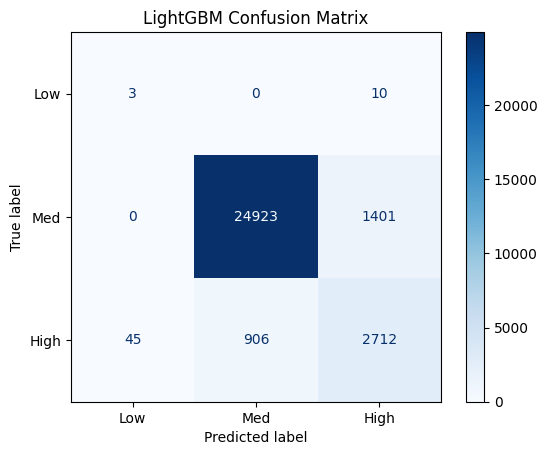

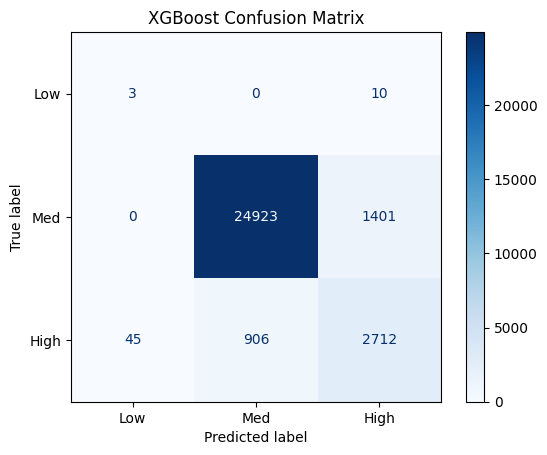

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

for name in top_models:

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Low", "Med", "High"],
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")
    plt.show()

**Confusion Matrix Analysis**

- The confusion matrices indicate that both LightGBM and XGBoost correctly classified the majority of Moderate burnout employees, resulting in high overall accuracy.
- Both models also demonstrated good performance in identifying High burnout cases, although some High burnout instances were misclassified as Moderate.
- The Low burnout class showed the highest misclassification rate, primarily due to its extremely small representation in the dataset.
- Overall, the confusion matrices reveal that the models perform reliably on the majority classes but face challenges in accurately predicting the severely underrepresented minority class.


Choosing **LightGBM** shows the best choice on choosing this because:

- ✅ Highest Macro F1 (0.58)
- ✅ Same overall accuracy as XGBoost
- ✅ Better F1 for the High burnout class
- ✅ Better recall for High burnout (important if missing high-risk employees is costly)

#### ROC Curves

In [ ]:
best_model = other_models["LightGBM"]
best_model

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,50
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


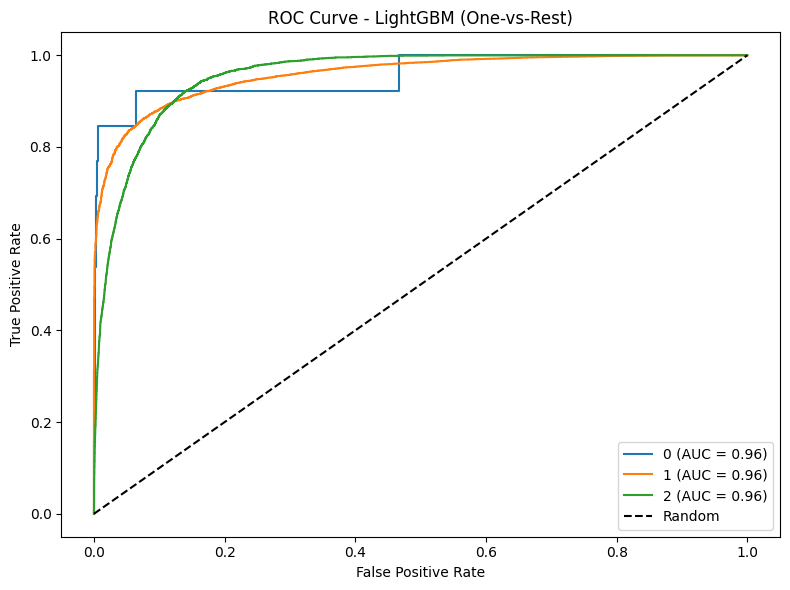

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np


# 1. Get probability scores (not just predictions)
y_prob = best_model.predict_proba(x_test)

# 2. Binarize the labels — one column per class
classes = best_model.classes_  # e.g. ['high', 'low', 'medium']
y_test_bin = label_binarize(y_test, classes=classes)

# 3. Plot one ROC curve per class
plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.2f})")

# 4. Diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM (One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.show()

**ROC Curve Analysis — Key Takeaways**

- All three classes scored AUC = 0.96 — excellent discrimination across low, medium, and high burnout
- Model performs equally well on all three classes — no class is being favored or neglected
- All curves hug the top-left corner tightly — meaning high true positive rate at very low false positive rate
- Far above the random baseline (dashed diagonal) — model is genuinely learning patterns, not guessing
- Class 0 (blue) curve is slightly jagged compared to the smooth orange and green — likely that class has fewer test samples, not a model issue
Overall the model is production-ready from a discrimination standpoint

In [ ]:
import joblib

# Save model
joblib.dump(other_models["LightGBM"], "backend/lightgbm_burnout.pkl")
print("✅ Model saved → backend/lightgbm_burnout.pkl")

# Save scaler
joblib.dump(scaler, "backend/scaler.pkl")
print("✅ Scaler saved → backend/scaler.pkl")

# Save label encoders dict
joblib.dump(label, "backend/label_encoders.pkl")
print("✅ Label encoders saved → backend/label_encoders.pkl")

print("\nAll artifacts saved. You can now run the FastAPI backend.")

FileNotFoundError: [Errno 2] No such file or directory: 'backend/lightgbm_burnout.pkl'